In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#E. Coli

# Load your CSV with headers from the file
ecoli = pd.read_csv("../ncbi_562_data.csv", skip_blank_lines=True)


category_map = {
    "Vegetable": ["lettuce", "spinach", "cilantro", "coriander", "alfalfa", "onion", "allium"],
    "Fruit": ["apple", "cantaloupe", "fruit"],
    "Chicken": ["chicken", "gallus gallus", "gallus gallus domesticus"],
    "Beef": ["cow", "bovine", "bos taurus", "calf", "steer"],
    "Pork": ["pig", "porcine", "sus scrofa", "swine"],
    "Turkey": ["turkey"],
    "Human": ["homo sapiens", "human", "patient"],
    "Water": ["water", "pond", "creek", "wastewater", "trough"],
    "Farm": ["farm", "feedlot", "manure", "environmental"],
    "Community": ["community", "surveillance", "groin", "wound", "abscess"]
}

def categorize(row):
    text = f"{row['isolation_source']} {row['host']}".lower()
    for category, keywords in category_map.items():
        if any(keyword in text for keyword in keywords):
            return category
    return "Other/Unknown"

ecoli['category'] = ecoli.apply(categorize, axis=1)

In [3]:
# Salmonella
# Load your CSV with headers from the file
salmonella = pd.read_csv("../ncbi_590_data.csv", skip_blank_lines=True)

category_map = {
    "Vegetable": ["lettuce", "spinach", "cilantro", "coriander", "alfalfa", "onion", "allium"],
    "Fruit": ["apple", "cantaloupe", "fruit"],
    "Chicken": ["chicken", "gallus gallus", "gallus gallus domesticus"],
    "Beef": ["cow", "bovine", "bos taurus", "calf", "steer"],
    "Pork": ["pig", "porcine", "sus scrofa", "swine"],
    "Turkey": ["turkey"],
    "Human": ["homo sapiens", "human", "patient"],
    "Water": ["water", "pond", "creek", "wastewater", "trough"],
    "Farm": ["farm", "feedlot", "manure", "environmental"],
    "Community": ["community", "surveillance", "groin", "wound", "abscess"]
}

def categorize(row):
    text = f"{row['isolation_source']} {row['host']}".lower()
    for category, keywords in category_map.items():
        if any(keyword in text for keyword in keywords):
            return category
    return "Other/Unknown"

salmonella['category'] = salmonella.apply(categorize, axis=1)

C:\Users\bryan\AppData\Local\Temp\ipykernel_7484\2140640865.py:3: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  salmonella = pd.read_csv("../ncbi_590_data.csv", skip_blank_lines=True)


In [4]:
ecoli = ecoli[ecoli['is_usa_based'] == 1]
ecoli['collection_year'] = pd.to_numeric(ecoli['collection_year'], errors='coerce')
ecoli = ecoli[ecoli['collection_year'] >= 2009]
ecoli = ecoli[ecoli['month'].notna()]
ecoli['collection_year'] = ecoli['collection_year'].astype(str)
ecoli['collection_year'] = ecoli['collection_year'].str[:4]
ecoli['month'] = ecoli['month'].astype(int)
ecoli['month'] = ecoli['month'].apply(lambda x: f"{x:02d}")
ecoli['year_and_month'] = ecoli['collection_year'] + '-' + ecoli['month']
ecoli['usa_state'] = ecoli['usa_state'].str.upper()
salmonella = salmonella[salmonella['is_usa_based'] == 1]
salmonella['collection_year'] = pd.to_numeric(salmonella['collection_year'], errors='coerce')
salmonella = salmonella[salmonella['collection_year'] >= 2009]
salmonella = salmonella[salmonella['month'].notna()]
salmonella['collection_year'] = salmonella['collection_year'].astype(str)
salmonella['collection_year'] = salmonella['collection_year'].str[:4]
salmonella['month'] = salmonella['month'].astype(int)
salmonella['month'] = salmonella['month'].apply(lambda x: f"{x:02d}")
salmonella['year_and_month'] = salmonella['collection_year'] + '-' + salmonella['month']
salmonella['usa_state'] = salmonella['usa_state'].str.upper()


In [5]:
ecoli.head()

,genome,geo_loc_name,collection_date,strain,host,serotype,isolate,isolation_source,source_type,submitter,geo_loc_name_is_missing,is_usa_based,usa_state,new_isolation_source,new_host,collection_year,month,nors_primary_mode_map,category,year_and_month
124,GCA_000508485.1,USA: Comer Children's Hospital at the Universi...,2012-02-10,NaN,Homo sapiens,NaN,NaN,NaN,NaN,"University of California, Berkeley",False,1.0,COLORADO,Uncategorized,Homo sapiens,2012,02,NaN,Human,2012-02
125,GCA_000508685.1,USA: Comer Children's Hospital at the Universi...,2012-02-10,NaN,Homo sapiens,NaN,NaN,NaN,NaN,"University of California, Berkeley",False,1.0,COLORADO,Uncategorized,Homo sapiens,2012,02,NaN,Human,2012-02
128,GCA_000522085.1,"USA: Boston, MA",2012-12,BIDMC 43b,Homo sapiens,NaN,NaN,BLOOD CULTURE,NaN,Broad Institute,False,1.0,MASSACHUSETTS,Uncategorized,Homo sapiens,2012,12,BLOOD CULTURE,Human,2012-12
129,GCA_000522105.1,"USA: Boston, MA",2012-12,BIDMC 43a,Homo sapiens,NaN,NaN,BLOOD CULTURE,NaN,Broad Institute,False,1.0,MASSACHUSETTS,Uncategorized,Homo sapiens,2012,12,BLOOD CULTURE,Human,2012-12
131,GCA_000522385.1,"USA: Boston, MA",2012-12,BIDMC 49a,Homo sapiens,NaN,NaN,BLOOD CULTURE,NaN,Broad Institute,False,1.0,MASSACHUSETTS,Uncategorized,Homo sapiens,2012,12,BLOOD CULTURE,Human,2012-12


In [6]:
heat_map_ecoli = ecoli[['usa_state', 'category']]
heat_map_ecoli = heat_map_ecoli[heat_map_ecoli['usa_state'] != "UNKNOWN"]
heat_map_ecoli = heat_map_ecoli[heat_map_ecoli['category'] != "Other/Unknown"]
heat_map_salmonella = salmonella[['usa_state', 'category']]
heat_map_salmonella = heat_map_salmonella[heat_map_salmonella['usa_state'] != "UNKNOWN"]
heat_map_salmonella = heat_map_salmonella[heat_map_salmonella['category'] != "Other/Unknown"]
heat_map_ecoli.to_csv('heat_map_ecoli.csv', index=False)
heat_map_salmonella.to_csv('heat_map_salmonella.csv', index=False)

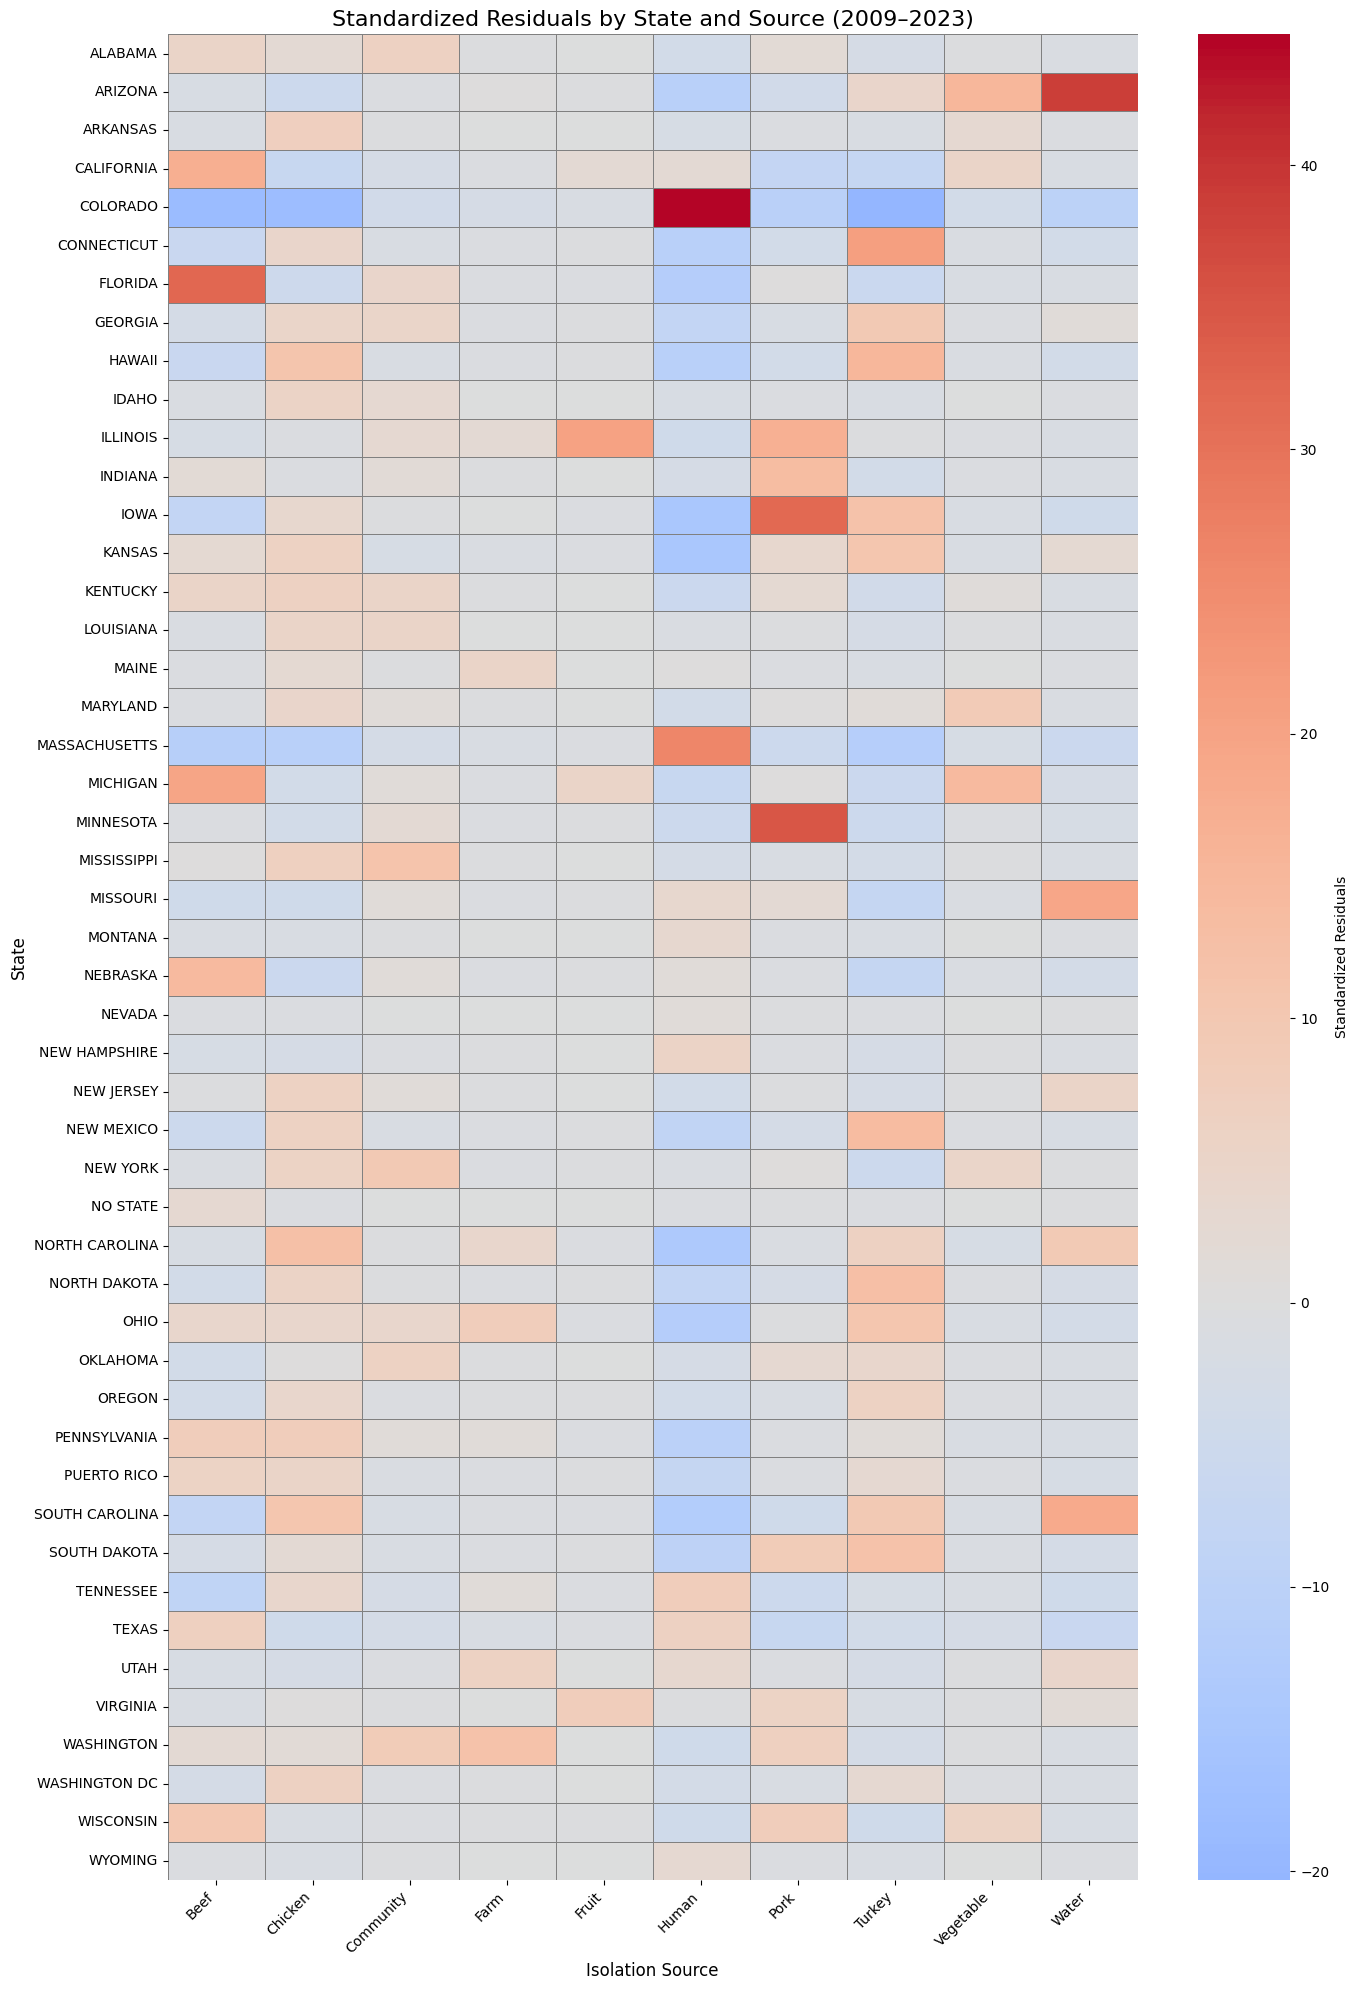

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create contingency table
observed = heat_map_ecoli.pivot_table(index='usa_state', columns='category', aggfunc='size', fill_value=0)

# Compute expected counts
row_totals = observed.sum(axis=1).values.reshape(-1, 1)
col_totals = observed.sum(axis=0).values.reshape(1, -1)
grand_total = observed.values.sum()
expected = row_totals @ col_totals / grand_total

# Standardized residuals
residuals = (observed.values - expected) / np.sqrt(expected)
residuals_df = pd.DataFrame(residuals, index=observed.index, columns=observed.columns)

# Plot heatmap with red for positive and blue for negative residuals
plt.figure(figsize=(14, 20))
sns.heatmap(residuals_df,
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            linecolor='gray',
            cbar_kws={'label': 'Standardized Residuals'},
            annot=False)

# Titles and labels
plt.title("Standardized Residuals by State and Source (2009–2023)", fontsize=16)
plt.xlabel("Isolation Source", fontsize=12)
plt.ylabel("State", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
top_ten = residuals_df.abs().stack().nlargest(10)
print(top_ten)

usa_state      category
COLORADO       Human       44.594970
ARIZONA        Water       38.704213
MINNESOTA      Pork        35.010281
FLORIDA        Beef        31.958916
IOWA           Pork        31.856190
MASSACHUSETTS  Human       26.298170
CONNECTICUT    Turkey      21.181802
COLORADO       Turkey      20.302230
ILLINOIS       Fruit       20.280763
MICHIGAN       Beef        19.750011
dtype: float64


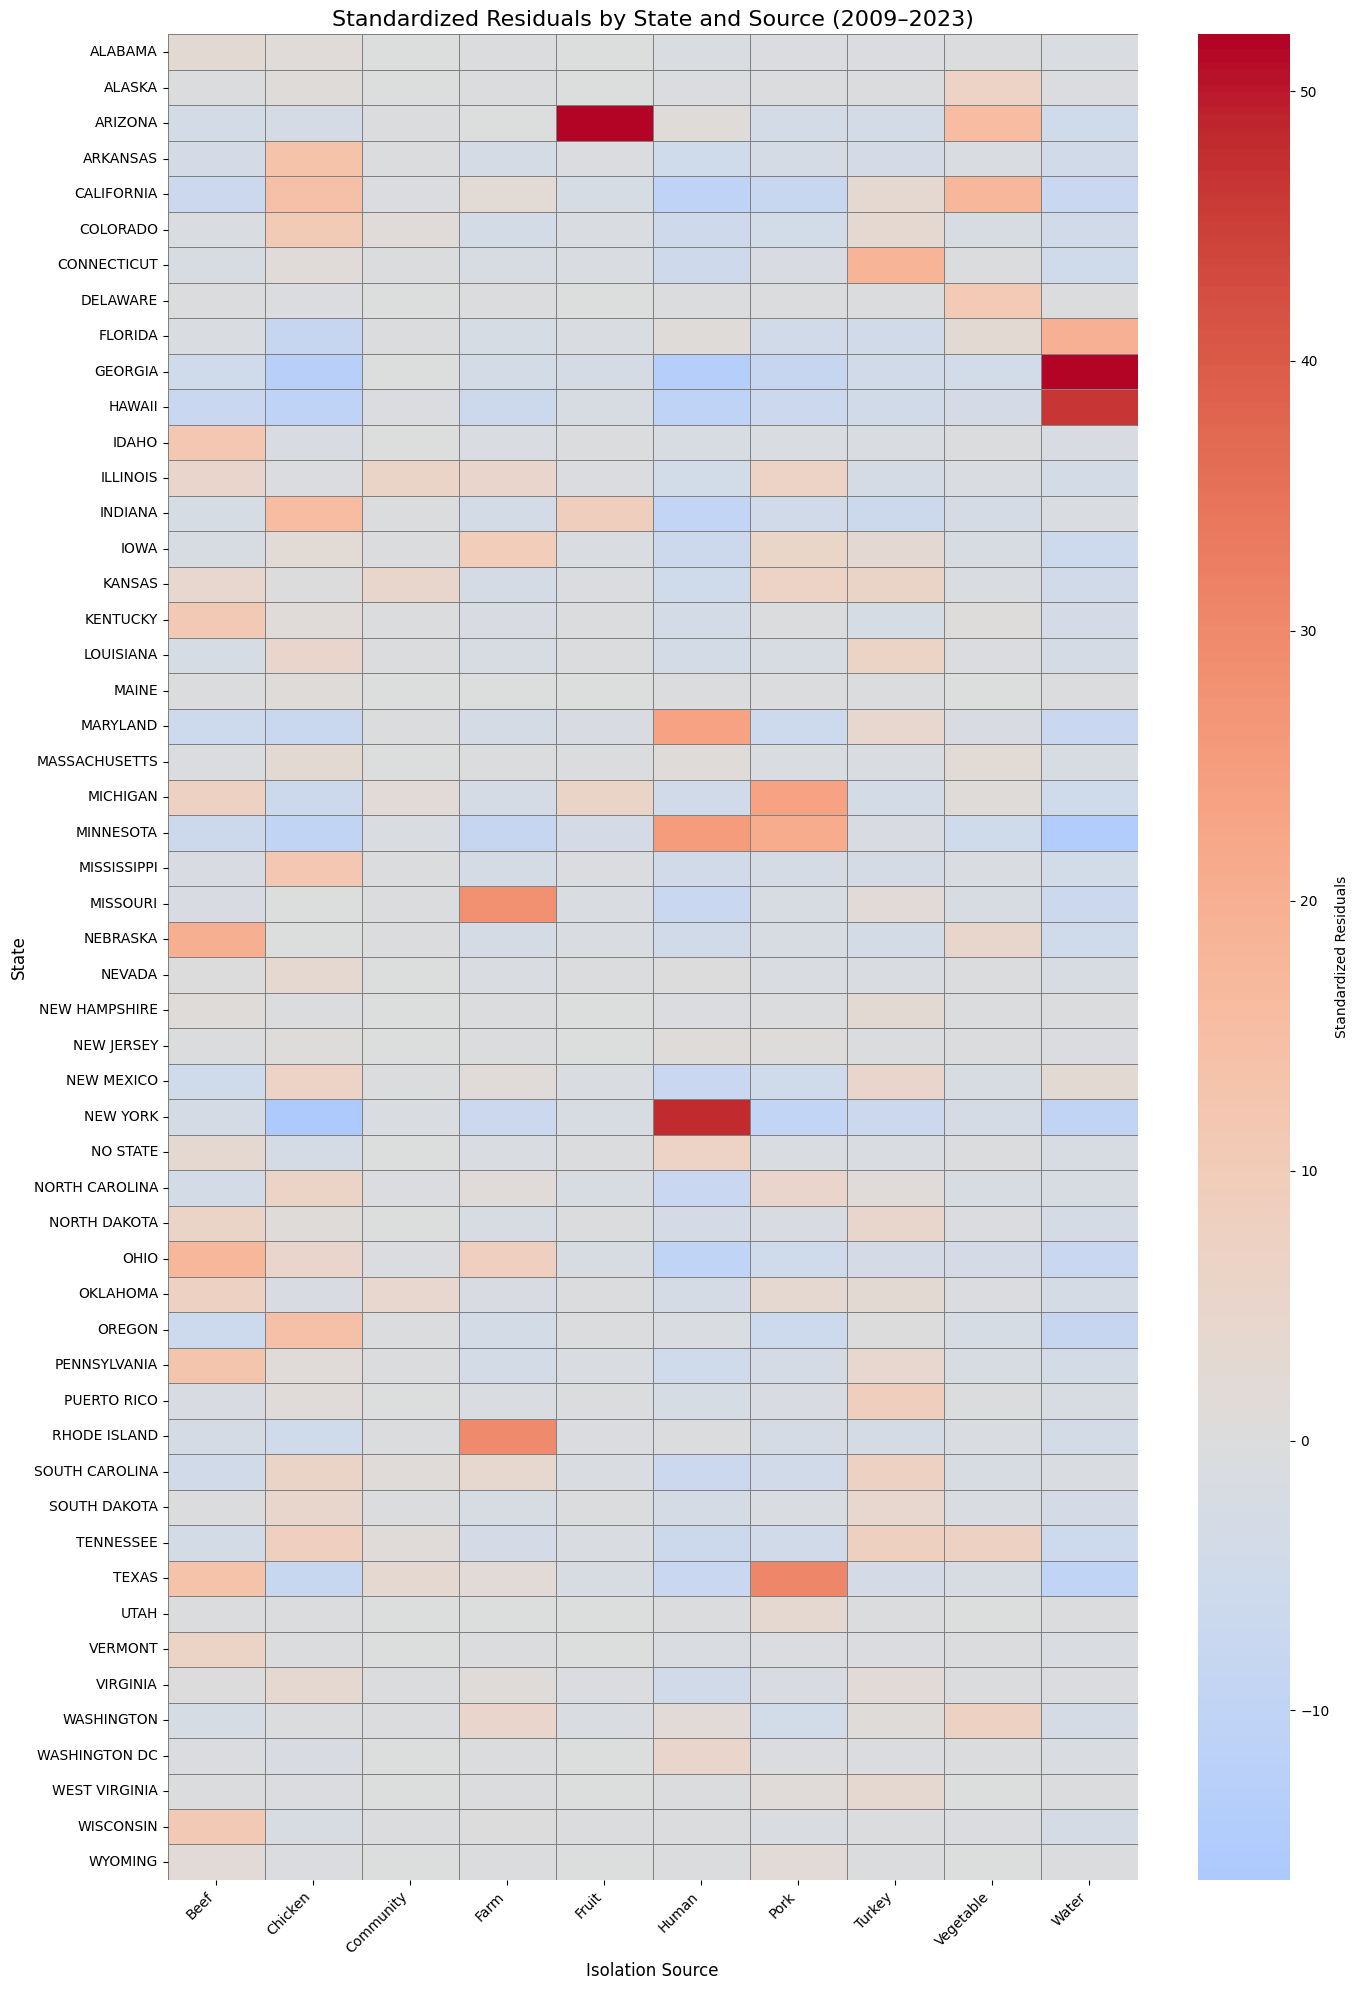

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create contingency table
observed = heat_map_salmonella.pivot_table(index='usa_state', columns='category', aggfunc='size', fill_value=0)

# Compute expected counts
row_totals = observed.sum(axis=1).values.reshape(-1, 1)
col_totals = observed.sum(axis=0).values.reshape(1, -1)
grand_total = observed.values.sum()
expected = row_totals @ col_totals / grand_total

# Standardized residuals
residuals = (observed.values - expected) / np.sqrt(expected)
residuals_df = pd.DataFrame(residuals, index=observed.index, columns=observed.columns)

# Plot heatmap with red for positive and blue for negative residuals
plt.figure(figsize=(14, 20))
sns.heatmap(residuals_df,
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            linecolor='gray',
            cbar_kws={'label': 'Standardized Residuals'},
            annot=False)

# Titles and labels
plt.title("Standardized Residuals by State and Source (2009–2023)", fontsize=16)
plt.xlabel("Isolation Source", fontsize=12)
plt.ylabel("State", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
#top ten absolute standardize residuals
top_ten = residuals_df.abs().stack().nlargest(10)
top_ten

usa_state     category
ARIZONA       Fruit       52.100211
GEORGIA       Water       51.978830
NEW YORK      Human       48.325200
HAWAII        Water       46.686138
TEXAS         Pork        30.683880
RHODE ISLAND  Farm        29.797237
MISSOURI      Farm        28.321914
MINNESOTA     Human       25.141188
MICHIGAN      Pork        23.785994
MARYLAND      Human       23.629964
dtype: float64

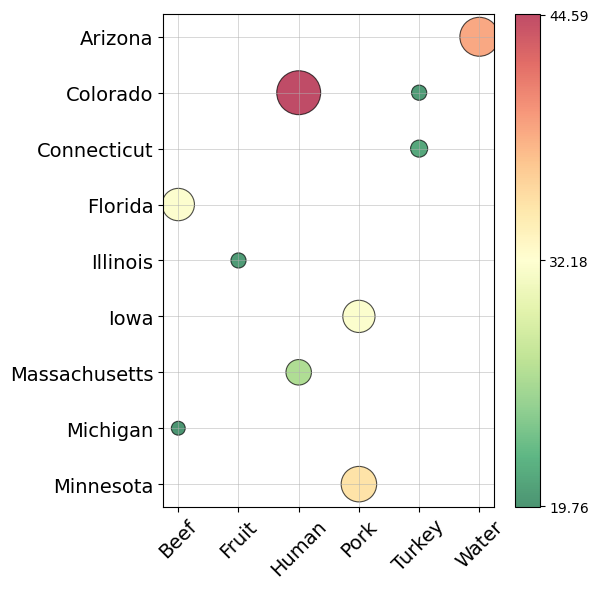

In [18]:
#E. Coli top 10 bubble
# Define the data with Proper Case for states
data = {
    'State': ['Colorado', 'Arizona', 'Minnesota', 'Florida', 'Iowa',
              'Massachusetts', 'Connecticut', 'Colorado', 'Illinois', 'Michigan'],
    'Source': ['Human', 'Water', 'Pork', 'Beef', 'Pork',
               'Human', 'Turkey', 'Turkey', 'Fruit', 'Beef'],
    'Value': [44.594970, 38.704213, 35.010281, 31.958916, 31.856190,
              26.298170, 21.181802, 20.302230, 20.280763, 19.750011]
}

df = pd.DataFrame(data)

# Map categorical values to numeric positions
source_map = {source: i for i, source in enumerate(sorted(set(df['Source'])))}
state_list = sorted(set(df['State']), reverse=True)  # reversed order
state_map = {state: i for i, state in enumerate(state_list)}

df['X'] = df['Source'].map(source_map)  # Source on X-axis
df['Y'] = df['State'].map(state_map)    # State on Y-axis (reversed)

# Scale bubble sizes
min_size = 100
max_size = 1000
value_scaled = np.interp(df['Value'], (df['Value'].min(), df['Value'].max()), (min_size, max_size))

# Plot
plt.figure(figsize=(6, 6))  # Ideal for side-by-side in Overleaf
scatter = plt.scatter(
    df['X'], df['Y'],
    s=value_scaled,
    alpha=0.7,
    c=df['Value'],
    cmap='RdYlGn_r',
    edgecolors='black',
    linewidths=0.8
)

# Customize axes
plt.xticks(list(source_map.values()), list(source_map.keys()), rotation=45)
plt.yticks(list(state_map.values()), list(state_map.keys()))

# Remove axis labels and title
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("")
plt.ylabel("")
plt.title("")

plt.colorbar(scatter, label='', ticks=[19.76, (19.76+44.59)/2, 44.59])


# Add gridlines
plt.grid(True, which='both', linestyle='-', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.savefig("Ecoli_bubble_chart.pdf", format='pdf')
plt.show()

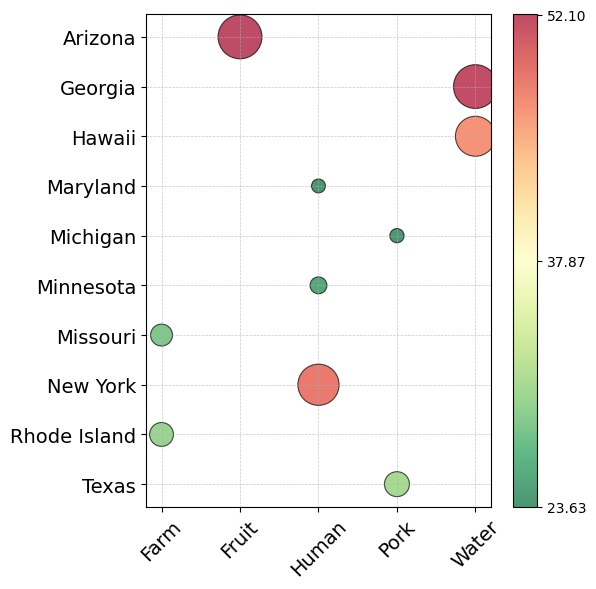

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Define the Salmonella data
data = {
    'State': ['Arizona', 'Georgia', 'New York', 'Hawaii', 'Texas',
              'Rhode Island', 'Missouri', 'Minnesota', 'Michigan', 'Maryland'],
    'Source': ['Fruit', 'Water', 'Human', 'Water', 'Pork',
               'Farm', 'Farm', 'Human', 'Pork', 'Human'],
    'Value': [52.100211, 51.978830, 48.325200, 46.686138, 30.683880,
              29.797237, 28.321914, 25.141188, 23.785994, 23.629964]
}

df = pd.DataFrame(data)

# Map categorical values to numeric positions
source_map = {source: i for i, source in enumerate(sorted(set(df['Source'])))}
state_list = sorted(set(df['State']), reverse=True)  # reversed order
state_map = {state: i for i, state in enumerate(state_list)}

df['X'] = df['Source'].map(source_map)  # Source on X-axis
df['Y'] = df['State'].map(state_map)    # State on Y-axis (reversed)

# Scale bubble sizes
min_size = 100
max_size = 1000
value_scaled = np.interp(df['Value'], (df['Value'].min(), df['Value'].max()), (min_size, max_size))

# Plot
plt.figure(figsize=(6, 6))  # Ideal for side-by-side in Overleaf
scatter = plt.scatter(
    df['X'], df['Y'],
    s=value_scaled,
    alpha=0.7,
    c=df['Value'],
    cmap='RdYlGn_r',
    edgecolors='black',
    linewidths=0.8,
)

# Customize axes
plt.xticks(list(source_map.values()), list(source_map.keys()), rotation=45)
plt.yticks(list(state_map.values()), list(state_map.keys()))

# Remove axis labels and title
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("")
plt.ylabel("")
plt.title("")
plt.colorbar(scatter, label='', ticks=[23.63, (23.63+52.10)/2, 52.10])


# Add gridlines
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.savefig("salmonella_bubble_chart.pdf", format='pdf')
plt.show()
